Accuracy for different K values:

K = 1  Accuracy = 97.78 %
K = 2  Accuracy = 98.06 %
K = 3  Accuracy = 98.33 %
K = 4  Accuracy = 98.06 %
K = 5  Accuracy = 98.61 %
K = 6  Accuracy = 98.89 %
K = 7  Accuracy = 98.89 %
K = 8  Accuracy = 98.61 %
K = 9  Accuracy = 98.06 %
K = 10  Accuracy = 98.33 %
K = 11  Accuracy = 98.33 %
K = 12  Accuracy = 97.78 %
K = 13  Accuracy = 97.78 %
K = 14  Accuracy = 98.06 %
K = 15  Accuracy = 97.78 %
K = 16  Accuracy = 98.06 %
K = 17  Accuracy = 98.33 %
K = 18  Accuracy = 98.06 %
K = 19  Accuracy = 97.5 %
K = 20  Accuracy = 97.78 %

Best K: 6
Best Accuracy: 98.89 %

Confusion Matrix:

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  0  1  1  0  0  0 38]]


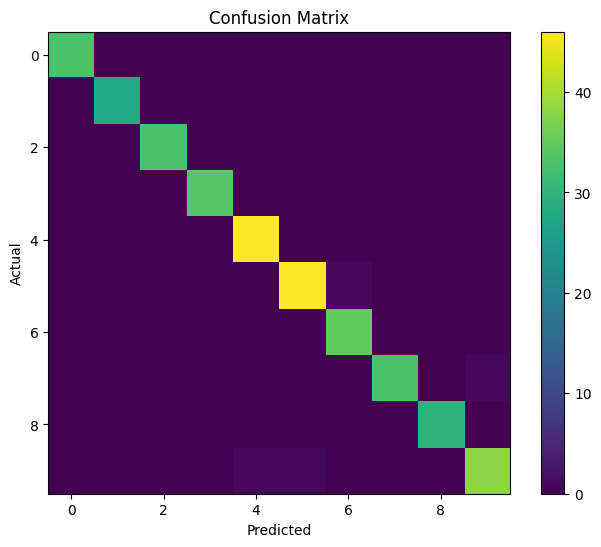


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [1]:
# Import libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np

# Load digits dataset
digits = load_digits()

X = digits.data
y = digits.target

# Split dataset
# 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# Find best K value
# -----------------------------------

best_k = 0
best_score = 0

print("Accuracy for different K values:\n")

for k in range(1,21):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train,y_train)

    y_pred = knn.predict(X_test)

    score = accuracy_score(
        y_test,
        y_pred
    )

    print(
        "K =",k,
        " Accuracy =",
        round(score*100,2),"%"
    )

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K:",best_k)
print("Best Accuracy:",round(best_score*100,2),"%")

# -----------------------------------
# Train model with best K
# -----------------------------------

model = KNeighborsClassifier(
    n_neighbors=best_k
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# -----------------------------------
# Confusion Matrix
# -----------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()

# -----------------------------------
# Classification Report
# -----------------------------------

report = classification_report(
    y_test,
    y_pred
)

print("\nClassification Report:\n")
print(report)